In [1]:
import jax
import sys
original_sys_path = sys.path.copy()
sys.path.append('../utils')
from utils_visualization import *
import scqubits
import numpy as np
from scipy.optimize import minimize


import sys
sys.path.append('../')
from utils_models import *



n_evals = 25
def get_chi(Er,ql1,elements,evals):
    return sum([get_shift_accurate(elements[ql1,ql2], evals[ql2], evals[ql1], Er) for ql2 in range(n_evals)] )

jax_get_chi = jax.jit(jax.vmap(get_chi,in_axes = (0,None,None,None)))


# def find_closest_transition(Er,evals):
#     arr = np.array([evals[7]-evals[0],
#                     evals[9]-evals[0],
#                     evals[11]-evals[0],
#                     evals[13]-evals[0]])
#     names = ['07','09','011','013']
#     differences = jnp.abs(arr - Er)
#     closest_index = jnp.argmin(differences)
#     return names[closest_index]

def get_transition(EJoverEL, EJoverEC):
    EJ = 4
    EL = EJ/EJoverEL
    EC = EJ/EJoverEC

    qbt = scqubits.Fluxonium(EJ = EJ,EC = EC,EL = EL, cutoff = 110,flux = 0,truncated_dim=n_evals)
    evals = qbt.eigenvals(n_evals)
    elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
    Er_list = np.linspace(evals[7]-evals[2],   evals[13]-evals[2],   int(1e6))

    chi0 = jax_get_chi(Er_list,0,elements,evals)
    chi1 = jax_get_chi(Er_list,1,elements,evals)
    chi2 = jax_get_chi(Er_list,2,elements,evals)


    zero_two_crossovers = np.nonzero(np.diff(np.sign(chi0[:] - chi2[:])))[0]
    results = []
    for crossover in zero_two_crossovers:
        if jnp.all(jnp.abs(chi1[crossover-10:crossover+10] - chi2[crossover-10:crossover+10]) < 1e-4):
            results.append([  Er_list[crossover]/EJ,
                            #  find_closest_transition(Er_list[crossover],evals),
                             jnp.abs(chi0[crossover] - chi1[crossover]).item()  ])
    

    return max(results, key=lambda t: t[-1]) if len(results) != 0 else [None,None]

In [9]:
EJoverEC_list =  np.linspace(2.5,4,40)
EJoverEL_list = np.linspace(25,34,40)

In [10]:
Er_over_EJ_grid = np.zeros((len(EJoverEL_list), len(EJoverEC_list)))
closest_transition_grid = np.empty((len(EJoverEL_list), len(EJoverEC_list)))
zero_one_diff_grid = np.empty((len(EJoverEL_list), len(EJoverEC_list)))

for i, EJoverEL in enumerate(EJoverEL_list):
    print(i)
    for j, EJoverEC in tqdm(enumerate(EJoverEC_list)):
        Er_over_EJ,zero_one_diff = get_transition(EJoverEL, EJoverEC)
        Er_over_EJ_grid[i, j] = Er_over_EJ
        # closest_transition_grid[i, j] = closest_transition
        zero_one_diff_grid[i, j] = zero_one_diff


0


40it [00:04,  8.73it/s]


1


40it [00:03, 12.25it/s]


2


...

40it [00:05,  6.77it/s]


38


40it [00:09,  4.37it/s]


39


40it [00:12,  3.22it/s]


In [8]:
# import pickle
# with open('../pickles/sweepECEL_gf.pkl', 'wb') as file:
#     pickle.dump((Er_over_EJ_grid,closest_transition_grid,zero_one_diff_grid), file)

In [3]:
# import pickle
# with open('../pickles/sweepECEL_gf.pkl', 'rb') as file:
#     Er_over_EJ_grid,closest_transition_grid,zero_one_diff_grid = pickle.load( file)


 /tmp/ipykernel_2741/3588889809.py: 2

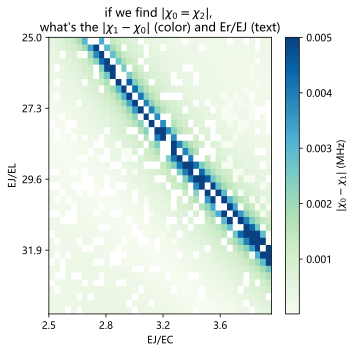

In [11]:
plt.figure(figsize=(5,5))
im = plt.imshow(zero_one_diff_grid/100, cmap= plt.cm.get_cmap('GnBu'),vmax = 5e-3,vmin = 1e-5,extent=[EJoverEC_list[0], EJoverEC_list[-1], EJoverEL_list[-1], EJoverEL_list[0]])

EroverEJ_trunc = np.trunc(Er_over_EJ_grid* 10) / 10

# for i in range(50)[5::5]:
#     for j in range(50)[5::5]:
#         plt.text(EJoverEC_list[i],EJoverEL_list[j],str(EroverEJ_trunc[i,j]),ha='center',va='center')


plt.xticks(ticks = EJoverEC_list[::10],labels = np.trunc(EJoverEC_list[::10] * 10) / 10  )
plt.yticks(ticks = EJoverEL_list[::10],labels =  np.trunc(EJoverEL_list[::10] * 10) / 10 )


cbar = plt.colorbar(im)
cbar.set_label(r'$|\chi_0-\chi_1|$ (MHz)')
plt.xlabel(rf'EJ/EC')
plt.ylabel(rf'EJ/EL')
plt.title(r'''if we find $|\chi_0=\chi_2|$, 
what's the $|\chi_1-\chi_0|$ (color) and Er/EJ (text)''')
plt.gca().set_aspect('auto')
# plt.savefig('fig01_where_to_find_good_params_fine_grid.pdf', format='pdf', bbox_inches='tight')


0


40it [00:03, 11.22it/s]


1


40it [00:04,  8.24it/s]


2


...

40it [00:05,  6.71it/s]


38


40it [00:04,  8.99it/s]


39


40it [00:04,  8.32it/s]
 /tmp/ipykernel_2741/2533700369.py: 15

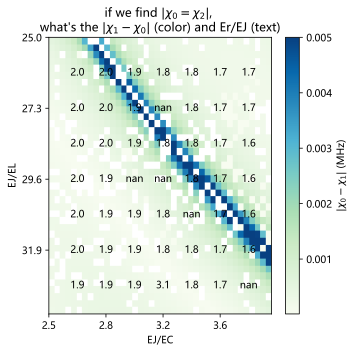

In [14]:
EJoverEC_list =  np.linspace(2.5,4,40)
EJoverEL_list = np.linspace(25,34,40)
Er_over_EJ_grid = np.zeros((len(EJoverEL_list), len(EJoverEC_list)))
closest_transition_grid = np.empty((len(EJoverEL_list), len(EJoverEC_list)))
zero_one_diff_grid = np.empty((len(EJoverEL_list), len(EJoverEC_list)))

for i, EJoverEL in enumerate(EJoverEL_list):
    print(i)
    for j, EJoverEC in tqdm(enumerate(EJoverEC_list)):
        Er_over_EJ,zero_one_diff = get_transition(EJoverEL, EJoverEC)
        Er_over_EJ_grid[i, j] = Er_over_EJ
        # closest_transition_grid[i, j] = closest_transition
        zero_one_diff_grid[i, j] = zero_one_diff
plt.figure(figsize=(5,5))
im = plt.imshow(zero_one_diff_grid/100, cmap= plt.cm.get_cmap('GnBu'),vmax = 5e-3,vmin = 1e-5,extent=[EJoverEC_list[0], EJoverEC_list[-1], EJoverEL_list[-1], EJoverEL_list[0]])

EroverEJ_trunc = np.trunc(Er_over_EJ_grid* 10) / 10

for i in range(40)[5::5]:
    for j in range(40)[5::5]:
        plt.text(EJoverEC_list[i],EJoverEL_list[j],str(EroverEJ_trunc[i,j]),ha='center',va='center')


plt.xticks(ticks = EJoverEC_list[::10],labels = np.trunc(EJoverEC_list[::10] * 10) / 10  )
plt.yticks(ticks = EJoverEL_list[::10],labels =  np.trunc(EJoverEL_list[::10] * 10) / 10 )


cbar = plt.colorbar(im)
cbar.set_label(r'$|\chi_0-\chi_1|$ (MHz)')
plt.xlabel(rf'EJ/EC')
plt.ylabel(rf'EJ/EL')
plt.title(r'''if we find $|\chi_0=\chi_2|$, 
what's the $|\chi_1-\chi_0|$ (color) and Er/EJ (text)''')
plt.gca().set_aspect('auto')
# plt.savefig('fig01_where_to_find_good_params_fine_grid.pdf', format='pdf', bbox_inches='tight')
